In [2]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import sys
import tifffile
import torch

from matplotlib.collections import PolyCollection
from shapely.ops import unary_union
from shapely.strtree import STRtree
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

sys.path.append("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1")
from norkin_organoid.code.get_embeddings import (
    create_organoid_regions,
    get_morphological_features,
    get_resnet152_embeddings,
    polygon_to_mask,
    visualize_cell_segmentation,
    NorkinOrganoidDataset,
)

%matplotlib inline

# What is our generic strategy?

1. Take all fo the norkin_organoid images
2. Begin to do preprocessing on them
3. Visualize them and see what a reasonable way to do organoid segmentation is

In [3]:
organoid_boundary_pth = "/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/data/xenium/raw/CRC_PDO/hImmune_v1_mm/1CFW/output-XETG00059__0021738__1CFW__20250319__172035/cell_boundaries.parquet"
pq = pd.read_parquet(organoid_boundary_pth)

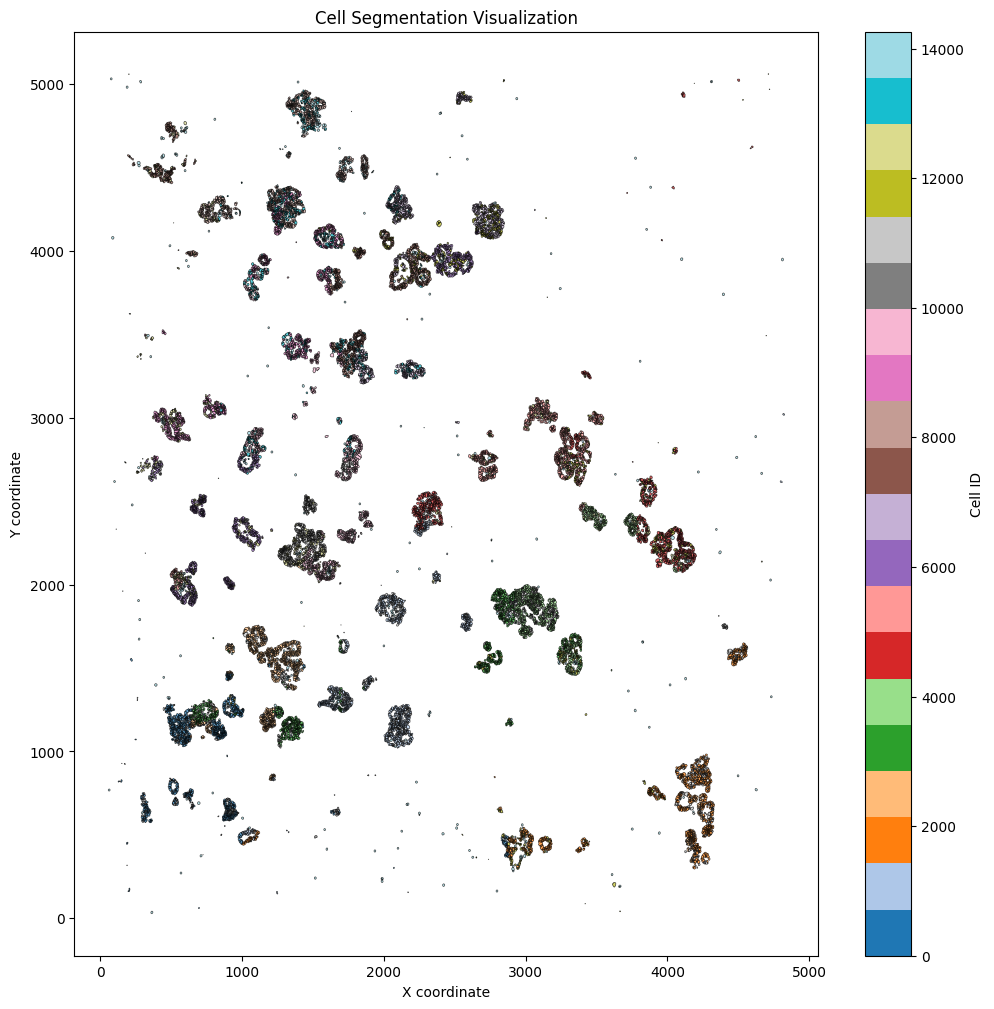

In [71]:
visualize_cell_segmentation(organoid_boundary_pth, limit=None)

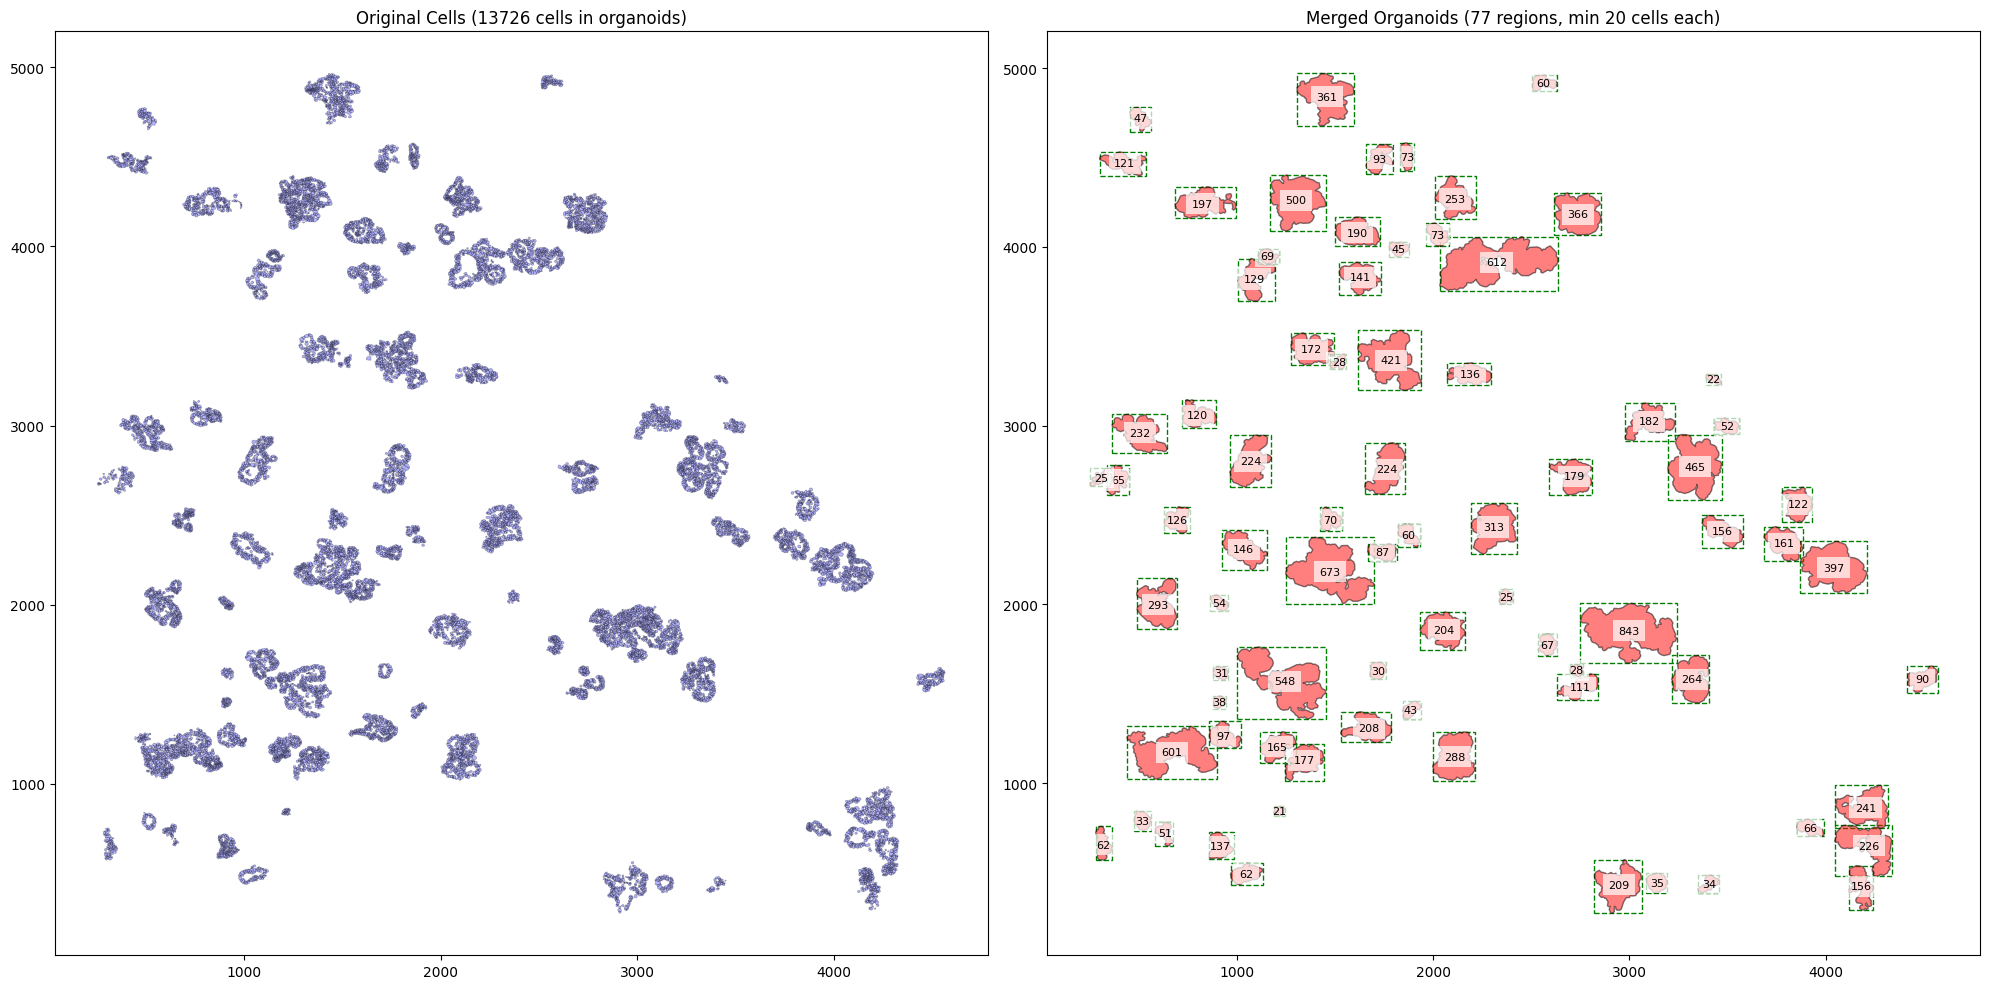

ValueError: too many values to unpack (expected 2)

In [4]:
# Example usage:
organoids, cell_counts, _ = create_organoid_regions(organoid_boundary_pth, 
                                                buffer_distance=5, 
                                                min_cell_count=20)

In [39]:
organoids[14]
sample = organoids[14]

In [4]:
polygon_to_mask(sample)

NameError: name 'polygon_to_mask' is not defined

In [3]:
dataset = NorkinOrganoidDataset()
dataset

Loading preprocessed masks from /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoid_masks.pkl


In [ ]:
dataset

In [10]:
def get_vit_embeddings(X): 
    """
    Get embeddings from a pre-trained Vision Transformer (ViT) model.
    
    Args:
        X: Input tensor of shape (N, 224, 224)
    Returns:
        embeddings: Tensor of shape (N, 768) with ViT embeddings
    """
    from torchvision import transforms
    from torchvision.models import vit_b_16
    import torch.nn.functional as F
    
    # Load pre-trained ViT model
    vit_model = vit_b_16(pretrained=True)
    vit_model.eval()

    # Apply transform and get embeddings
    with torch.no_grad():
        embeddings = vit_model(X)
    
    return F.normalize(embeddings, dim=-1)  # Normalize embeddings for consistency

In [29]:
masks = dataset[:]
morphological_features = get_morphological_features(masks[0])
masks = masks.swapaxes(0, 1).repeat(1, 3, 1, 1)

Calculating morphological features:   0%|          | 0/2012 [00:00<?, ?it/s]

Calculating morphological features: 100%|██████████| 2012/2012 [00:15<00:00, 132.27it/s]


In [28]:
len(morphological_features)

2026

In [8]:
morph_data_df = pd.DataFrame(morphological_features)
morph_data_df = morph_data_df.map(lambda value: value[0])
morph_data_matrix = morph_data_df.values

# map each item in morph_data_matrix => item[0]
from sklearn.preprocessing import MinMaxScaler

# Apply MinMaxScaler to scale each column to the range [0, 1]
scaler = MinMaxScaler()
morph_data_matrix = scaler.fit_transform(morph_data_matrix)
morph_data_matrix.shape


    

(2012, 7)

In [11]:
embeddings = get_resnet152_embeddings(masks, morphological_features=morph_data_matrix, fine_tune=True)

/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


: 

: 

In [25]:
X = dataset[:].squeeze().unsqueeze(1).repeat((1, 3, 1, 1))
embed = get_vit_embeddings(X)


/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [50]:
with open("vit_embeddings.pkl", "wb") as f:
    pickle.dump(embed, f)

In [6]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.preprocessing import MinMaxScaler

# Use widget backend for interactive plots
%matplotlib inline

def create_umap_with_mask_hover(embeddings, binary_masks, n_samples=None, random_state=42):
    """
    Jupyter-optimized UMAP visualization with binary mask hover.
    
    Parameters:
    - embeddings: (N, embed_dim) array
    - binary_masks: (N, 224, 224) binary masks
    - n_samples: number of samples to display
    - random_state: random seed
    """
    # Sample if requested
    if n_samples is not None and n_samples < len(embeddings):
        rng = np.random.RandomState(random_state)
        indices = rng.choice(len(embeddings), n_samples, replace=False)
        embeddings = embeddings[indices]
        binary_masks = binary_masks[indices]
    
    # UMAP reduction
    reducer = umap.UMAP(random_state=random_state)
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # Normalize coordinates
    scaler = MinMaxScaler()
    coords = scaler.fit_transform(umap_embeddings)
    
    # Create figure with specific DPI
    fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
    scatter = ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5)
    plt.title("UMAP with Binary Mask Hover")
    
    # Prepare image boxes
    image_boxes = []
    for mask in binary_masks:
        mask = (mask > 0).astype(float)  # Ensure binary
        img_box = OffsetImage(mask, cmap='gray', zoom=0.3)
        image_boxes.append(img_box)
    
    # Create annotation initially hidden
    annot = AnnotationBbox(image_boxes[0], (0,0), 
                          xybox=(50,50),
                          xycoords='data',
                          boxcoords="offset points",
                          pad=0.5,
                          arrowprops=dict(arrowstyle="->"))
    annot.set_visible(False)
    ax.add_artist(annot)
    
    # Hover function
    def update_annot(ind):
        pos = scatter.get_offsets()[ind]
        annot.xy = pos
        annot.set_visible(True)
        annot.offsetbox = image_boxes[ind]
        fig.canvas.draw_idle()
    
    # Motion notify event
    def hover(event):
        vis = annot.get_visible()
        if event.inaxes == ax:
            cont, ind = scatter.contains(event)
            if cont:
                update_annot(ind["ind"][0])
            else:
                if vis:
                    annot.set_visible(False)
                    fig.canvas.draw_idle()
    
    fig.canvas.mpl_connect("motion_notify_event", hover)
    plt.show()

embedding_matrix = embed
masks = dataset[:][0]
create_umap_with_mask_tooltips(embedding_matrix, masks)

NameError: name 'create_umap_with_mask_tooltips' is not defined

/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


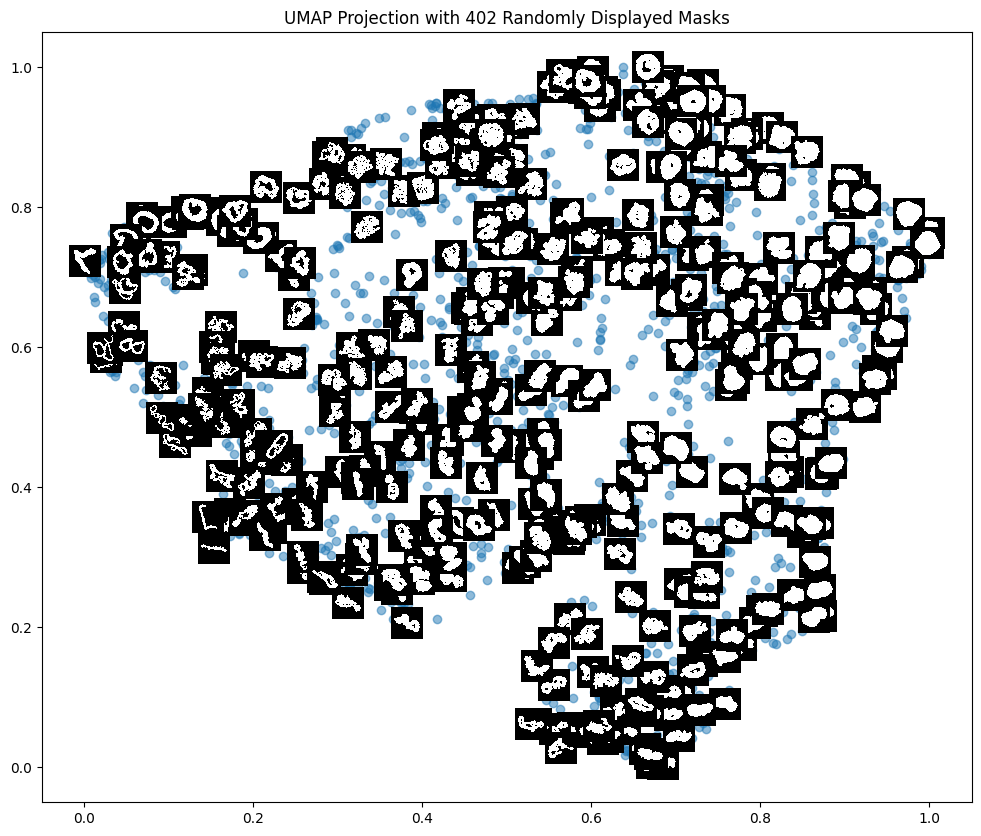

In [4]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.preprocessing import MinMaxScaler

# Use inline backend
%matplotlib inline

def create_umap_with_displayed_masks(embeddings, binary_masks, patient_ids, display_ratio=0.1, random_state=42):
    """
    UMAP visualization with randomly sampled masks displayed directly on plot.
    
    Parameters:
    - embeddings: (N, embed_dim) array
    - binary_masks: (N, 224, 224) binary masks
    - display_ratio: fraction of images to display (0 to 1)
    - random_state: random seed
    """
    # Calculate number of images to display
    n_display = max(1, int(len(embeddings) * display_ratio))
    
    # Randomly select indices for display
    rng = np.random.RandomState(random_state)
    display_indices = rng.choice(len(embeddings), n_display, replace=False)
    
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(random_state=random_state)
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # Normalize coordinates to [0,1] for better plotting
    scaler = MinMaxScaler()
    coords = scaler.fit_transform(umap_embeddings)
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
    
    # Plot all points
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5)
    plt.title(f"UMAP Projection with {n_display} Randomly Displayed Masks")
    
    # Display selected masks
    for idx in display_indices:
        # Get binary mask and normalize to [0,1]
        mask = binary_masks[idx].numpy()
        
        # Create image box
        img_box = OffsetImage(mask, cmap='gray', zoom=0.1)  # Smaller zoom for better visibility
        
        # Create annotation at UMAP coordinates
        ab = AnnotationBbox(img_box, 
                          (coords[idx, 0], coords[idx, 1]),
                          frameon=False,
                          pad=0.1)
        ax.add_artist(ab)
    
    plt.show()

# Example usage:
embed = pickle.load(open("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/code/embeddings_resnet152.pkl", "rb"))
embedding_matrix = embed
masks = dataset[:][0]
create_umap_with_displayed_masks(embedding_matrix, masks, dataset.organoid_patient_ids, display_ratio=0.2)

/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_3157831/3074170059.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv', num_patients)


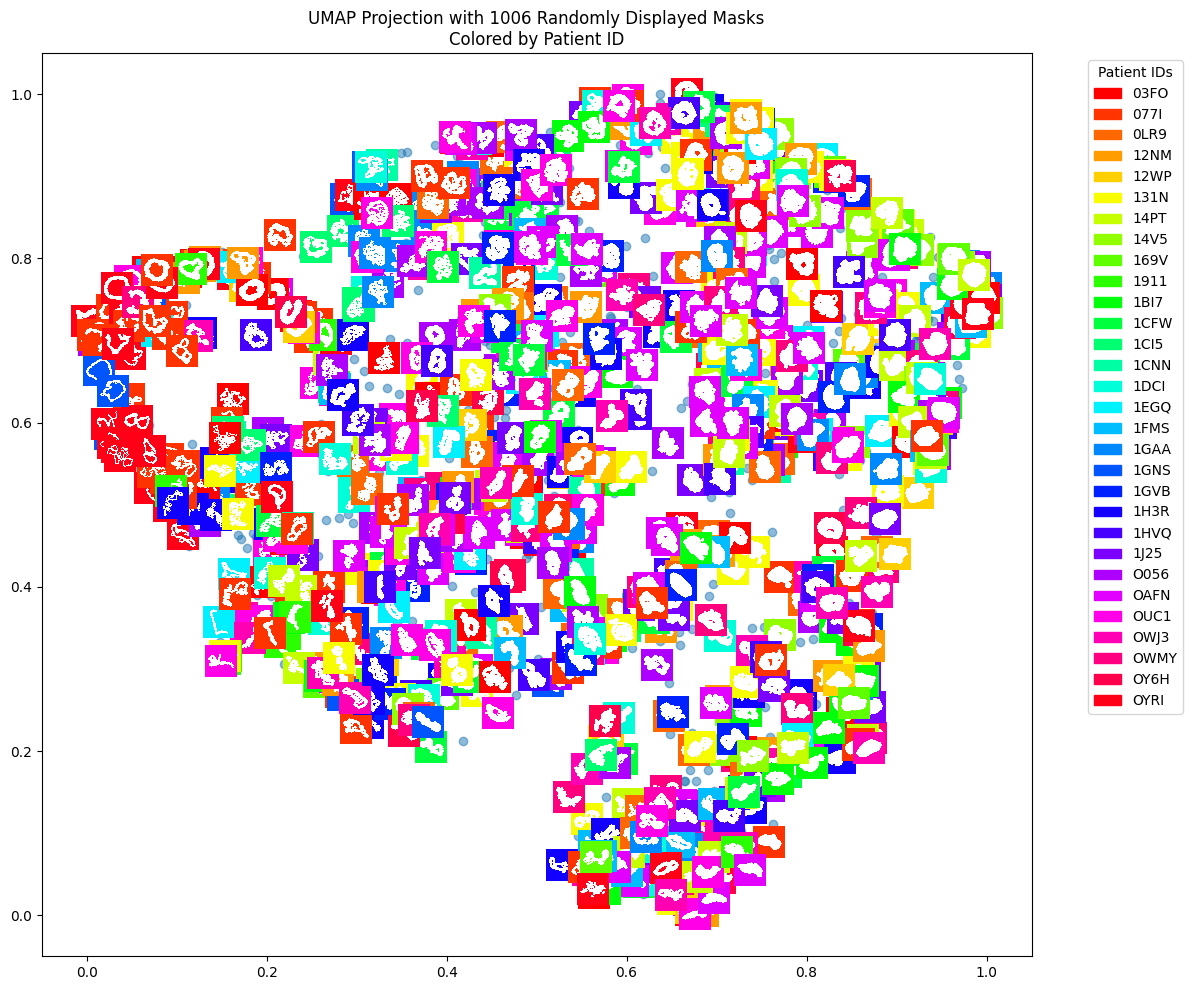

In [5]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.preprocessing import MinMaxScaler
import matplotlib.patches as mpatches

def create_umap_with_displayed_masks(embeddings, binary_masks, patient_ids, display_ratio=0.1, random_state=42):
    """
    UMAP visualization with randomly sampled masks displayed directly on plot.
    Each displayed mask has a background color based on patient ID.
    
    Parameters:
    - embeddings: (N, embed_dim) array
    - binary_masks: (N, 224, 224) binary masks
    - patient_ids: list of patient IDs (strings) corresponding to each mask
    - display_ratio: fraction of images to display (0 to 1)
    - random_state: random seed
    """
    # Calculate number of images to display
    n_display = max(1, int(len(embeddings) * display_ratio))
    
    # Randomly select indices for display
    rng = np.random.RandomState(random_state)
    display_indices = rng.choice(len(embeddings), n_display, replace=False)
    
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(random_state=random_state)
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # Normalize coordinates to [0,1] for better plotting
    scaler = MinMaxScaler()
    coords = scaler.fit_transform(umap_embeddings)
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
    
    # Plot all points
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5)
    plt.title(f"UMAP Projection with {n_display} Randomly Displayed Masks\nColored by Patient ID")
    
    # Create color mapping for patient IDs
    unique_patients = np.unique(patient_ids)
    num_patients = len(unique_patients)
    
    # Create a colormap with enough distinct colors
    cmap = plt.cm.get_cmap('hsv', num_patients)
    patient_to_color = {patient: cmap(i) for i, patient in enumerate(unique_patients)}
    
    # Display selected masks with patient-colored background
    for idx in display_indices:
        # Get binary mask
        mask = binary_masks[idx].numpy()
        
        # Create a colored background (RGBA array)
        bg_color = patient_to_color[patient_ids[idx]]
        bg_array = np.zeros((*mask.shape, 4))  # Create RGBA array
        bg_array[..., :3] = bg_color[:3]  # Set RGB
        bg_array[..., 3] = 1  # Set alpha (transparency)
        
        # Combine mask with background
        display_img = np.where(mask[..., None] > 0, 
                             np.array([1, 1, 1, 1]),  # White for mask
                             bg_array)  # Colored background
        
        # Create image box
        img_box = OffsetImage(display_img, zoom=0.1)
        
        # Create annotation at UMAP coordinates
        ab = AnnotationBbox(img_box, 
                          (coords[idx, 0], coords[idx, 1]),
                          frameon=False,
                          pad=0.1)
        ax.add_artist(ab)
    
    # Create legend
    legend_patches = [mpatches.Patch(color=patient_to_color[pid], label=pid) 
                     for pid in unique_patients]
    ax.legend(handles=legend_patches, 
              title='Patient IDs',
              bbox_to_anchor=(1.05, 1), 
              loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Example usage:
embed = pickle.load(open("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/code/embeddings_resnet152.pkl", "rb"))
embedding_matrix = embed
masks = dataset[:][0]
create_umap_with_displayed_masks(embedding_matrix, masks, dataset.organoid_patient_ids, display_ratio=0.5)

## Cluster the embeddings

In [9]:
embedding_matrix.shape
len(dataset.organoid_patient_ids)

2012

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def find_optimal_k(embedding_matrix, max_k=10):
    """
    Perform K-means clustering for different k values and plot the results
    to help determine the optimal k using the elbow method.
    
    Parameters:
    - embedding_matrix: N x d numpy array of embeddings
    - max_k: maximum number of clusters to try
    
    Returns:
    - None (displays plot)
    """
    # Check input shape
    if len(embedding_matrix.shape) != 2:
        raise ValueError("Input must be a 2D matrix (N x d)")
    
    N, d = embedding_matrix.shape
    if N < 2:
        raise ValueError("Need at least 2 samples for clustering")
    
    # Calculate distortion (inertia) and silhouette score for different k values
    distortions = []
    silhouette_scores = []
    k_values = range(1, max_k+1)
    
    for k in k_values:
        if k == 1:
            # Special case for k=1 (no actual clustering)
            distortions.append(np.sum((embedding_matrix - np.mean(embedding_matrix, axis=0))**2))
            silhouette_scores.append(0)  # Silhouette score is undefined for k=1
        else:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
            kmeans.fit(embedding_matrix)
            distortions.append(kmeans.inertia_)
            
            # Silhouette score requires at least 2 clusters
            if k > 1:
                silhouette_scores.append(silhouette_score(embedding_matrix, kmeans.labels_))
            else:
                silhouette_scores.append(0)
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot elbow method (distortion)
    ax1.plot(k_values, distortions, 'bx-')
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Distortion (Inertia)')
    ax1.set_title('Elbow Method')
    ax1.grid(True)
    
    # Plot silhouette scores
    ax2.plot(k_values[1:], silhouette_scores[1:], 'rx-')
    ax2.set_xlabel('Number of clusters (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Method')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()


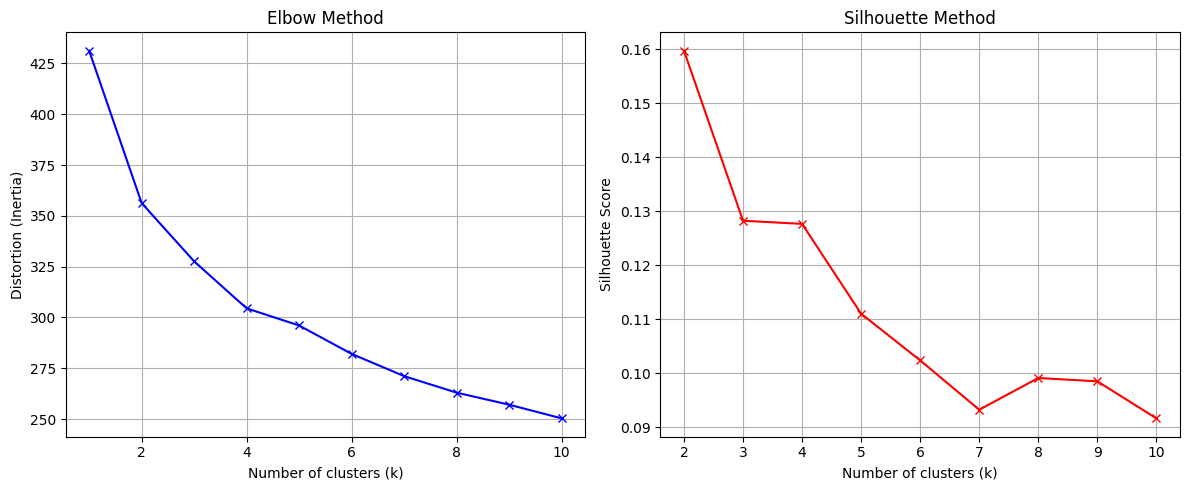

In [12]:
find_optimal_k(embedding_matrix.numpy())

/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_3157831/3031668066.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', k)
/tmp/ipykernel_3157831/3031668066.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  patient_cmap = plt.cm.get_cmap('hsv', num_patients)


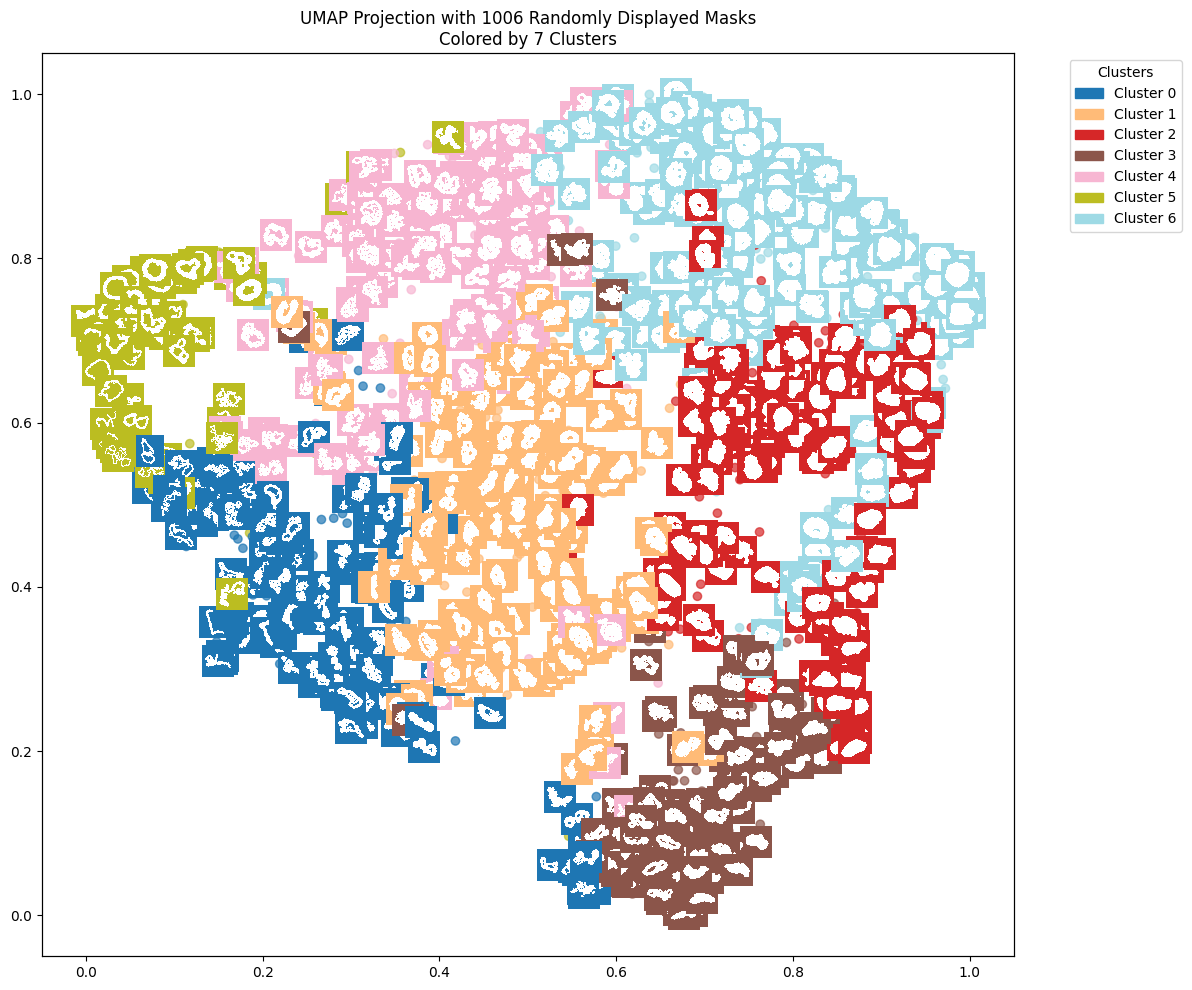

In [14]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches

def create_umap_with_cluster_masks(embeddings, binary_masks, patient_ids=None, k=7, display_ratio=0.1, random_state=42):
    """
    UMAP visualization with randomly sampled masks displayed directly on plot.
    Each displayed mask has a background color based on cluster assignment.
    
    Parameters:
    - embeddings: (N, embed_dim) array
    - binary_masks: (N, 224, 224) binary masks
    - patient_ids: optional list of patient IDs (strings) for reference
    - k: number of clusters for K-means
    - display_ratio: fraction of images to display (0 to 1)
    - random_state: random seed
    """
    # Perform K-means clustering
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init='auto')
    clusters = kmeans.fit_predict(embeddings)
    
    # Calculate number of images to display
    n_display = max(1, int(len(embeddings) * display_ratio))
    
    # Randomly select indices for display
    rng = np.random.RandomState(random_state)
    display_indices = rng.choice(len(embeddings), n_display, replace=False)
    
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(random_state=random_state)
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # Normalize coordinates to [0,1] for better plotting
    scaler = MinMaxScaler()
    coords = scaler.fit_transform(umap_embeddings)
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
    
    # Plot all points colored by cluster
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='tab20', alpha=0.7)
    plt.title(f"UMAP Projection with {n_display} Randomly Displayed Masks\nColored by {k} Clusters")
    
    # Create colormap for clusters
    cmap = plt.cm.get_cmap('tab20', k)
    
    # Display selected masks with cluster-colored background
    for idx in display_indices:
        # Get binary mask
        mask = binary_masks[idx].numpy()
        
        # Get cluster color
        cluster_color = cmap(clusters[idx])
        
        # Create a colored background (RGBA array)
        bg_array = np.zeros((*mask.shape, 4))  # Create RGBA array
        bg_array[..., :3] = cluster_color[:3]  # Set RGB
        bg_array[..., 3] = 1  # Set alpha (transparency)
        
        # Combine mask with background
        display_img = np.where(mask[..., None] > 0, 
                             np.array([1, 1, 1, 1]),  # White for mask
                             bg_array)  # Colored background
        
        # Create image box
        img_box = OffsetImage(display_img, zoom=0.1)
        
        # Create annotation at UMAP coordinates
        ab = AnnotationBbox(img_box, 
                          (coords[idx, 0], coords[idx, 1]),
                          frameon=False,
                          pad=0.1)
        ax.add_artist(ab)
    
    # Create legend for clusters
    cluster_patches = [mpatches.Patch(color=cmap(i), label=f'Cluster {i}') 
                      for i in range(k)]
    ax.legend(handles=cluster_patches, 
              title='Clusters',
              bbox_to_anchor=(1.05, 1), 
              loc='upper left')
    
    # Optionally add patient IDs to legend if provided
    if patient_ids is not None:
        unique_patients = np.unique(patient_ids)
        num_patients = len(unique_patients)
        patient_cmap = plt.cm.get_cmap('hsv', num_patients)
        patient_patches = [mpatches.Patch(color=patient_cmap(i), label=pid) 
                          for i, pid in enumerate(unique_patients)]
        
        # Create a second legend for patient IDs
        ax2 = ax.twinx()
        # ax2.legend(handles=patient_patches,
        #           title='Patient IDs',
        #           bbox_to_anchor=(1.05, 0.7),
        #           loc='upper left')
        ax2.set_ylabel('')  # Remove ylabel
        ax2.set_yticks([])  # Remove yticks
    
    plt.tight_layout()
    plt.show()

# Example usage:
embed = pickle.load(open("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/code/embeddings_resnet152.pkl", "rb"))
embedding_matrix = embed
masks = dataset[:][0]
create_umap_with_cluster_masks(embedding_matrix, masks, dataset.organoid_patient_ids, k=7, display_ratio=0.5)

/tmp/ipykernel_3157831/2334864322.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_clusters))


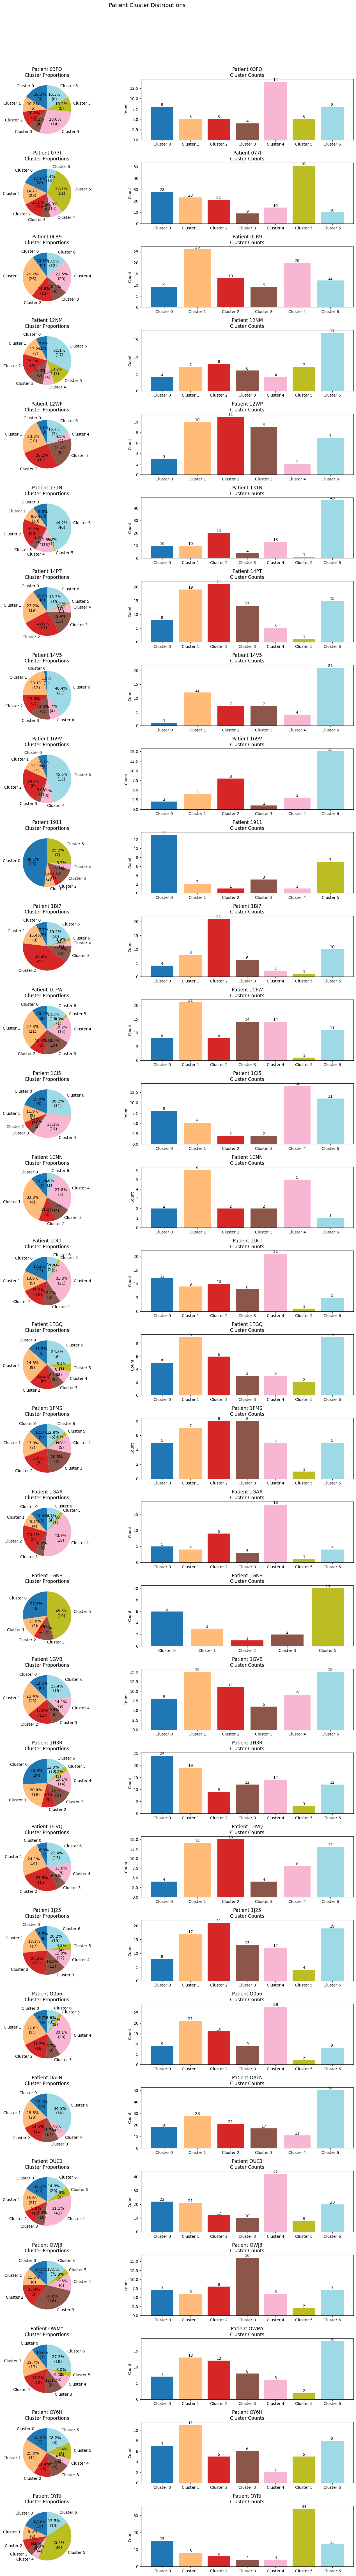

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def visualize_patient_cluster_distribution(patient_ids, cluster_assignments, max_patients_to_show=10):
    """
    Create pie charts and bar charts showing cluster distribution for each patient.
    
    Parameters:
    - patient_ids: list of length N with patient IDs (strings)
    - cluster_assignments: list of length N with cluster numbers (integers)
    - max_patients_to_show: maximum number of patients to visualize (for space reasons)
    """
    # Create mapping of patient to cluster counts
    patient_cluster_counts = defaultdict(lambda: defaultdict(int))
    unique_clusters = np.unique(cluster_assignments)
    
    for pid, cluster in zip(patient_ids, cluster_assignments):
        patient_cluster_counts[pid][cluster] += 1
    
    # Get unique patients and limit to max_patients_to_show
    unique_patients = sorted(patient_cluster_counts.keys())
    if len(unique_patients) > max_patients_to_show:
        print(f"Showing first {max_patients_to_show} of {len(unique_patients)} patients")
        unique_patients = unique_patients[:max_patients_to_show]
    
    # Create colormap for clusters
    cmap = plt.cm.get_cmap('tab20', len(unique_clusters))
    
    # Create figure with subplots
    fig, axes = plt.subplots(len(unique_patients), 2, figsize=(15, 3 * len(unique_patients)))
    fig.suptitle('Patient Cluster Distributions', y=1.02, fontsize=14)
    
    if len(unique_patients) == 1:
        axes = np.array([axes])  # Ensure axes is 2D even for single patient
    
    for i, patient_id in enumerate(unique_patients):
        # Get counts for this patient
        counts = patient_cluster_counts[patient_id]
        clusters = sorted(counts.keys())
        values = [counts[c] for c in clusters]
        total = sum(values)
        
        # Pie chart
        ax_pie = axes[i, 0]
        wedges, texts, autotexts = ax_pie.pie(
            values, 
            labels=[f'Cluster {c}' for c in clusters],
            autopct=lambda p: f'{p:.1f}%\n({int(round(p*total/100))})',
            colors=[cmap(c) for c in clusters],
            startangle=90
        )
        ax_pie.set_title(f'Patient {patient_id}\nCluster Proportions')
        
        # Bar chart
        ax_bar = axes[i, 1]
        bars = ax_bar.bar(
            [f'Cluster {c}' for c in clusters],
            values,
            color=[cmap(c) for c in clusters]
        )
        ax_bar.set_title(f'Patient {patient_id}\nCluster Counts')
        ax_bar.set_ylabel('Count')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax_bar.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}',
                        ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Example usage:
patient_ids = dataset.organoid_patient_ids
kmeans = KMeans(n_clusters=7, random_state=42, n_init='auto')
cluster_assignments = kmeans.fit_predict(embedding_matrix)
visualize_patient_cluster_distribution(patient_ids, cluster_assignments, max_patients_to_show=40)

# UMAP Colored by Morphological Features

In [19]:
masks = dataset[:]
morphological_features = get_morphological_features(masks[0])

Calculating morphological features: 100%|██████████| 2012/2012 [00:15<00:00, 131.63it/s]


In [ ]:
morphological_features

[{'area': np.float64(19796.0),
  'perimeter': np.float64(634.4406922210657),
  'eccentricity': 0.6103947713303239,
  'solidity': np.float64(0.9404722314599269),
  'extent': np.float64(0.704985754985755),
  'major_axis_length': 180.40062150421045,
  'minor_axis_length': 142.89485551357038,
  'convex_hull_blank_percentage': np.float64(5.9527768540073165)},
 {'area': np.float64(14474.0),
  'perimeter': np.float64(644.097546470558),
  'eccentricity': 0.8719559329772361,
  'solidity': np.float64(0.8833150250213597),
  'extent': np.float64(0.5089310829817159),
  'major_axis_length': 199.80798249004653,
  'minor_axis_length': 97.82286432999183,
  'convex_hull_blank_percentage': np.float64(11.668497497864031)},
 {'area': np.float64(18622.0),
  'perimeter': np.float64(1198.4966081312812),
  'eccentricity': 0.6421820730847427,
  'solidity': np.float64(0.7903739230083613),
  'extent': np.float64(0.6232262382864793),
  'major_axis_length': 200.4438250659972,
  'minor_axis_length': 153.650643272468

/users/lmcconn1/graph_archetype_discovery/gad/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


> /tmp/ipykernel_3157831/1251189946.py(53)create_umap_with_regression_values()
     51         reg = LinearRegression()
     52         import pdb; pdb.set_trace()
---> 53         reg.fit(embeddings, morph_features[:, i])
     54         predicted_values = reg.predict(embeddings)
     55 

(2012, 2048)
(2026,)
(2026,)


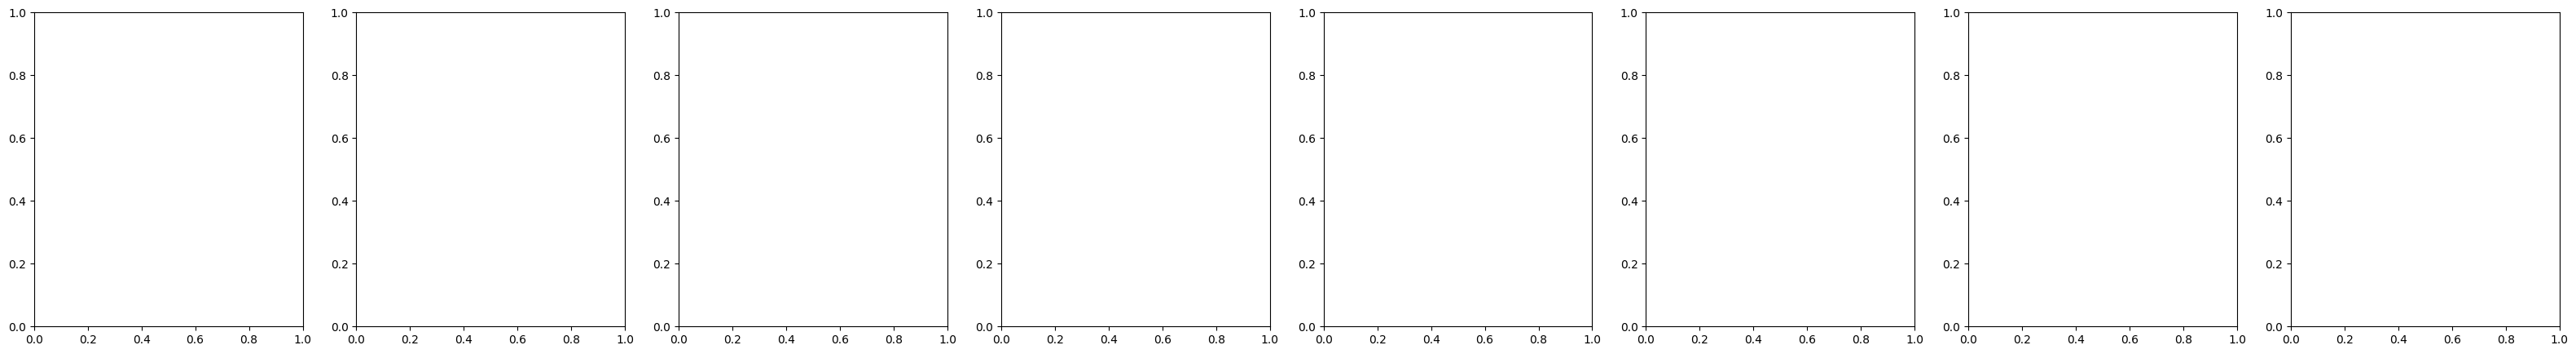

In [26]:
import numpy as np
import umap
import torch
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from matplotlib.colors import Normalize
from tqdm import tqdm

def create_umap_with_regression_values(embeddings, binary_masks, morphological_dicts, 
                                     display_ratio=0.1, random_state=42):
    """
    UMAP visualization with morphological feature regression values displayed as mask background colors.
    
    Parameters:
    - embeddings: torch.Tensor (N, embed_dim) - will be converted to numpy
    - binary_masks: (N, 224, 224) binary masks
    - morphological_dicts: list of N dicts containing morphological features (values must be np.float64)
    - display_ratio: fraction of images to display (0 to 1)
    - random_state: random seed
    """
    # Convert embeddings to numpy if needed
    if torch.is_tensor(embeddings):
        embeddings = embeddings.numpy()
    
    # Prepare morphological features
    feature_names = list(morphological_dicts[0].keys())
    num_features = len(feature_names)
    morph_features = np.array([[d[f] for f in feature_names] for d in morphological_dicts])
    
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(random_state=random_state)
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # Normalize coordinates to [0,1] for better plotting
    scaler = MinMaxScaler()
    coords = scaler.fit_transform(umap_embeddings)
    
    # Create figure with subplots for each feature
    fig, axes = plt.subplots(1, num_features, figsize=(5*num_features, 5))
    if num_features == 1:
        axes = [axes]  # Ensure axes is iterable
    
    # Create viridis colormap
    cmap = plt.cm.viridis
    
    # For each morphological feature
    for i, (feature_name, ax) in enumerate(zip(feature_names, axes)):
        # Fit linear regression
        reg = LinearRegression()
        import pdb; pdb.set_trace()
        reg.fit(embeddings, morph_features[:, i])
        predicted_values = reg.predict(embeddings)
        
        # Normalize predicted values for coloring
        norm = Normalize(vmin=predicted_values.min(), vmax=predicted_values.max())
        
        # Calculate number of images to display
        n_display = max(1, int(len(embeddings) * display_ratio))
        
        # Randomly select indices for display
        rng = np.random.RandomState(random_state)
        display_indices = rng.choice(len(embeddings), n_display, replace=False)
        
        # Plot all points colored by predicted value
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=predicted_values, cmap=cmap, alpha=0.5)
        plt.colorbar(sc, ax=ax, label=f'Predicted {feature_name}')
        ax.set_title(f"UMAP with {feature_name} Regression Values")
        
        # Display selected masks with color-coded background
        for idx in tqdm(display_indices, desc=f'Processing {feature_name}'):
            # Get binary mask
            mask = binary_masks[idx].numpy() if torch.is_tensor(binary_masks[idx]) else binary_masks[idx]
            
            # Get color for this sample
            color_val = norm(predicted_values[idx])
            color_rgba = cmap(color_val)
            
            # Create a colored background (RGBA array)
            bg_array = np.zeros((*mask.shape, 4))  # Create RGBA array
            bg_array[..., :3] = color_rgba[:3]  # Set RGB from colormap
            bg_array[..., 3] = 0.7  # Set alpha (semi-transparent)
            
            # Combine mask with background
            display_img = np.where(mask[..., None] > 0, 
                                 np.array([1, 1, 1, 1]),  # White for mask
                                 bg_array)  # Colored background
            
            # Create image box
            img_box = OffsetImage(display_img, zoom=0.1)
            
            # Create annotation at UMAP coordinates
            ab = AnnotationBbox(img_box, 
                              (coords[idx, 0], coords[idx, 1]),
                              frameon=False,
                              pad=0.1)
            ax.add_artist(ab)
    
    plt.tight_layout()
    plt.show()

# Example usage:
embeddings = embedding_matrix.numpy()
morph_dicts = morphological_features  # Convert to list of dicts
create_umap_with_regression_values(embeddings, masks, morph_dicts, display_ratio=0.2)

(27256, 25665)


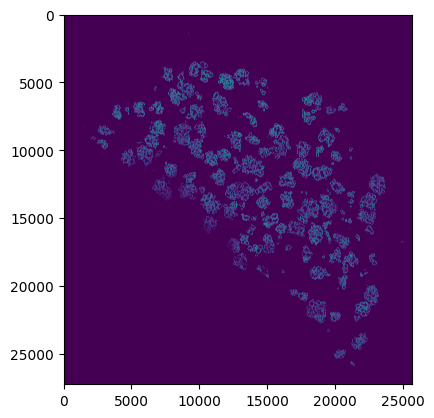

In [66]:
im = tifffile.imread("/work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/raw/CRC_PDO/hImmune_v1_dapi/0LR9/output-XETG00059__0003881__0RL9_not_OZ84__20250505__170804/aux_outputs/per_cycle_channel_images/cycle_01_blu.tiff")
im = tifffile.imread("/work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/raw/CRC_PDO/hImmune_v1_dapi/0LR9/output-XETG00059__0003881__0RL9_not_OZ84__20250505__170804/morphology_focus/morphology_focus_0000.ome.tif")
print(im.shape)
plt.imshow(im)

In [67]:
im = tifffile.imread("/work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/raw/CRC_PDO/hImmune_v1_dapi/0LR9/output-XETG00059__0003881__0RL9_not_OZ84__20250505__170804/morphology.ome.tif")
print(im.shape)
plt.imshow(im)

(13, 27256, 25665)


: 

: 